# Pedestrian MOT + Annotation Pipeline + Demo Video Synthesis

1. **Load fine-tuned Faster R-CNN from Step 2**
2. **Step 3: Multi-Object Tracking** via BoxMOT, comparing three algorithms
3. **Step 4: Annotation** via Supervision
4. **Comparison visualizations:** ground truth vs. tracked boxes, side-by-side
   tracker comparisons, a frame-by-frame sequence view, and motion traces.
5. **Step 5 scaffold:** creates an annotated video from Cityscapes `demoVideo` frames


In [2]:
# Install dependencies
# %pip install -q boxmot supervision opencv-python-headless


In [3]:
# Define all imports
import os
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import animation
from IPython.display import HTML, display

from boxmot.trackers.bbox import OcSort, DeepOcSort, StrongSort
import supervision as sv

import torch
from torchvision.transforms import functional as TF
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [4]:
# Define all constants
RAND_STATE = 498
DATASET_ROOT = Path("./Citypersons")
SPLIT = "val"
CITY = "frankfurt"
IMG_EXTS = (".png", ".jpg", ".jpeg")

# For simulating shifting frames
SEQUENCE_SOURCE = "synthetic"
RNG = np.random.default_rng(RAND_STATE)

FASTERRCNN_WEIGHTS_PATH = Path("fasterrcnn_citypersons.pth")
DETECTOR_SCORE_THRESHOLD = 0.5
NUM_CLASSES = 2  # background + pedestrian

# Comparison constants
SYNTH_PARAMS = dict(n_frames=15, pan_px=6.0, jitter_px=2.0,
                     occlude_track=0, occlude_frames=(6, 7, 8))
GREEN, RED = (60, 200, 60), (40, 40, 220)  # BGR, for cv2 drawing

# Video constants
FRAMES_DIR = Path("stuttgart_00")
MAX_FRAMES = None
FRAME_FPS = 17
RESIZE_WIDTH = None
OUTPUT_VIDEO_PATH = Path("tracked_output.mp4")

# Tracker for video synthesis: "OC-SORT", "DeepOCSORT", "StrongSORT"
TRACKER_NAME = "DeepOCSORT"

In [5]:
# Check if GPU is available via Cuda or MPS (Mac)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


## Load Fine-Tuned Faster R-CNN Model

In [6]:
# Load the fine-tuned Faster R-CNN detector from previous notebook.
def load_fasterrcnn_detector(weights_path=FASTERRCNN_WEIGHTS_PATH, device=device):
    '''Rebuild the exact architecture from the FineTuning notebook and load the fine-tuned weights.'''
    if not Path(weights_path).exists():
        raise FileNotFoundError(
            f"Couldn't find '{weights_path}'."
        )
    model = fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    return model


detector_model = load_fasterrcnn_detector()
print(f"Loaded fine-tuned Faster R-CNN from '{FASTERRCNN_WEIGHTS_PATH}' on {device}.")

# Function to detect pedestrians in a single frame
def detect_pedestrians(image_bgr, model=detector_model, device=device,
                        score_threshold=DETECTOR_SCORE_THRESHOLD):
    '''Run the fine-tuned detector on one OpenCV (BGR) frame.
    Returns an (N, 6) float32 array [x1, y1, x2, y2, conf, cls]
    cls is always 0 ("pedestrian")'''
    img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    img_tensor = TF.to_tensor(img_rgb).to(device)

    with torch.no_grad():
        # Make the prediction
        prediction = model([img_tensor])[0]

    boxes  = prediction["boxes"].cpu().numpy()
    scores = prediction["scores"].cpu().numpy()

    keep = scores >= score_threshold
    boxes, scores = boxes[keep], scores[keep]

    if boxes.shape[0] == 0:
        return np.zeros((0, 6), dtype=np.float32)

    cls = np.zeros((boxes.shape[0],), dtype=np.float32)  # single "person" class
    return np.concatenate([boxes, scores[:, None].astype(np.float32), cls[:, None]], axis=1).astype(np.float32)


Loaded fine-tuned Faster R-CNN from 'fasterrcnn_citypersons.pth' on mps.


## Run Fine-tuned detector on labeled data.

In [7]:
def find_city_images(dataset_root: Path, split: str, city: str, exts=IMG_EXTS):
    '''Locate city images from the dataset folder. Returns a sorted list of Path objects.'''
    dataset_root = Path(dataset_root)
    nested = dataset_root / "images" / split / city
    if nested.is_dir():
        files = [p for p in nested.iterdir() if p.suffix.lower() in exts]
        if files:
            return sorted(files)
    flat = dataset_root / "images" / split
    if flat.is_dir():
        files = [p for p in flat.iterdir() if p.suffix.lower() in exts and p.name.startswith(city)]
        if files:
            return sorted(files)
    return []


def find_label_for_image(image_path: Path, dataset_root: Path, split: str, city: str):
    '''Mirror an image path into the labels/ tree (nested or flat layout).'''
    dataset_root = Path(dataset_root)
    stem = image_path.stem
    nested = dataset_root / "labels" / split / city / f"{stem}.txt"
    if nested.exists():
        return nested
    flat = dataset_root / "labels" / split / f"{stem}.txt"
    if flat.exists():
        return flat
    return None

# Load the YOLO-style label file and convert to pixel coordinates
def load_yolo_label(label_path, img_w, img_h):
    '''Parse a YOLO-style label file ->
    (N, 5) array of [x1, y1, x2, y2, class_id] in pixel coordinates.'''
    if label_path is None or not Path(label_path).exists():
        return np.zeros((0, 5), dtype=np.float32)
    rows = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, xc, yc, w, h = (float(x) for x in parts[:5])
            x1 = (xc - w / 2) * img_w
            y1 = (yc - h / 2) * img_h
            x2 = (xc + w / 2) * img_w
            y2 = (yc + h / 2) * img_h
            rows.append([x1, y1, x2, y2, cls])
    if not rows:
        return np.zeros((0, 5), dtype=np.float32)
    return np.array(rows, dtype=np.float32)


In [8]:
# Run Frankfurt val images through the detector and load their ground-truth boxes
image_paths = find_city_images(DATASET_ROOT, SPLIT, CITY)
print(f"Found {len(image_paths)} images for {CITY}/{SPLIT}.")

real_frames = []
for p in image_paths:
    img = cv2.imread(str(p))
    if img is None:
        warnings.warn(f"Could not read {p}, skipping.")
        continue
    h, w = img.shape[:2]
    label_path = find_label_for_image(p, DATASET_ROOT, SPLIT, CITY)
    gt_boxes = load_yolo_label(label_path, w, h)
    det_boxes = detect_pedestrians(img)
    real_frames.append({"path": p, "image": img, "gt": gt_boxes, "det": det_boxes})

for f in real_frames[:5]:
    print(f["path"].name, "-> people:", f["gt"].shape[0])


Found 269 images for frankfurt/val.


frankfurt_000000_000294_leftImg8bit.png -> people: 4
frankfurt_000000_000576_leftImg8bit.png -> people: 2
frankfurt_000000_001016_leftImg8bit.png -> people: 3
frankfurt_000000_001236_leftImg8bit.png -> people: 13
frankfurt_000000_001751_leftImg8bit.png -> people: 6


In [9]:
def build_synthetic_motion_sequence(base_image, base_gt, n_frames=15, pan_px=6.0,
                                     jitter_px=2.0, occlude_track=0,
                                     occlude_frames=(6, 7, 8), rng=RNG):
    '''Turn one real annotated frame into a short pseudo-video by panning the
    camera and jittering each box a little every frame, so tracking has genuine
    frame-to-frame motion to follow.'''
    h, w = base_image.shape[:2]
    sequence = []
    for i in range(n_frames):
        dx, dy = pan_px * i, 0.0
        M = np.array([[1, 0, dx], [0, 1, dy]], dtype=np.float32)
        frame_img = cv2.warpAffine(base_image, M, (w, h), borderMode=cv2.BORDER_REFLECT)

        boxes = base_gt.copy()
        boxes[:, [0, 2]] += dx
        boxes[:, [1, 3]] += dy
        boxes[:, :4] += rng.normal(0, jitter_px, size=(boxes.shape[0], 4))

        is_occluded_now = occlude_track is not None and i in occlude_frames
        # For testing occlusion handling
        if is_occluded_now:
            pad = 6
            ox1, oy1, ox2, oy2 = boxes[occlude_track, :4]
            ox1c = max(0, int(ox1) - pad)
            oy1c = max(0, int(oy1) - pad)
            ox2c = min(w - 1, int(ox2) + pad)
            oy2c = min(h - 1, int(oy2) + pad)
            cv2.rectangle(frame_img, (ox1c, oy1c), (ox2c, oy2c), (110, 110, 110), -1)
        det = detect_pedestrians(frame_img)  # real Step-2 model output on the (possibly occluded) frame

        sequence.append({"frame_idx": i, "image": frame_img, "det": det})
    return sequence


# Pick the real frame with the most annotated people
base_frame = max(real_frames, key=lambda f: f["gt"].shape[0])
print(f"Using {base_frame['path'].name} ({base_frame['gt'].shape[0]} people) as the "
      f"basis for the synthetic pseudo-sequence.")

synthetic_sequence = build_synthetic_motion_sequence(base_frame["image"], base_frame["gt"], **SYNTH_PARAMS)

# Ground truth number of identities in the base frame (for later evaluation)
n_identities = base_frame["gt"].shape[0]

if SEQUENCE_SOURCE == "synthetic":
    sequence = synthetic_sequence
else:
    sequence = [{"frame_idx": i, "image": f["image"], "det": f["det"]}
                for i, f in enumerate(real_frames)]

print(f"SEQUENCE_SOURCE = '{SEQUENCE_SOURCE}' -> {len(sequence)} frames, "
      f"{[f['det'].shape[0] for f in sequence]} detections per frame.")

Using frankfurt_000001_017101_leftImg8bit.png (53 people) as the basis for the synthetic pseudo-sequence.
SEQUENCE_SOURCE = 'synthetic' -> 15 frames, [39, 41, 42, 42, 42, 43, 44, 41, 44, 44, 44, 40, 45, 40, 44] detections per frame.


## Multi-Object Tracking with BoxMOT


| Tracker | Motion | Appearance | Notes |
|---|---|---|---|
| **OC-SORT** | ✓ | – | Lightweight; assumes roughly linear motion through occlusion |
| **DeepOCSORT** | ✓ | ✓ | Adds appearance re-ID on top of OC-SORT's motion model |
| **StrongSORT** | ✓ | ✓ | Appearance-heavy; better at reducing ID switches in crowds, costlier |


In [10]:
def extract_color_histogram_embeddings(image, boxes_xyxy, bins=(8, 8, 8)):
    '''Alternative embedding due to bug in ReID embedding.'''
    n = boxes_xyxy.shape[0]
    dim = bins[0] * bins[1] * bins[2]
    if n == 0:
        return np.zeros((0, dim), dtype=np.float32)
    h, w = image.shape[:2]
    feats = np.zeros((n, dim), dtype=np.float32)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    for i, (x1, y1, x2, y2) in enumerate(boxes_xyxy):
        x1c, y1c = max(0, int(x1)), max(0, int(y1))
        x2c, y2c = min(w, int(x2)), min(h, int(y2))
        if x2c <= x1c or y2c <= y1c:
            continue
        crop = hsv[y1c:y2c, x1c:x2c]
        hist = cv2.calcHist([crop], [0, 1, 2], None, list(bins), [0, 180, 0, 256, 0, 256])
        feats[i] = cv2.normalize(hist, None).flatten()
    return feats.astype(np.float32)

def build_trackers():
    return {
        "OC-SORT": OcSort(),
        "DeepOCSORT": DeepOcSort(reid_model=None, embedding_off=False),
        "StrongSORT": StrongSort(reid_model=None),
    }


def run_tracker_over_sequence(name, tracker, seq):
    '''Run one tracker across a frame sequence.
    Return: a list of (M, 8) [x1, y1, x2, y2, track_id, conf, cls, det_ind] arrays, one per frame.'''
    out = []
    for f in seq:
        img, dets = f["image"], f["det"]
        if name == "OC-SORT":
            tracks = tracker.update(dets, img)
        else:
            embs = extract_color_histogram_embeddings(img, dets[:, :4])
            tracks = tracker.update(dets, img, embs=embs)
        out.append(np.asarray(tracks))
    return out

# Run all trackers over the sequence and collect results
trackers = build_trackers()
tracking_results = {}
for name, trk in trackers.items():
    tracking_results[name] = run_tracker_over_sequence(name, trk, sequence)
    counts = [r.shape[0] for r in tracking_results[name]]
    print(f"{name:12s} -> tracks/frame: {counts}")


INFO     OcSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,           
         class_ids=None, asso_func=iou, min_conf=0.1, delta_t=3, inertia=0.2, use_byte=False, Q_xy_scaling=0.01,   
         Q_s_scaling=0.0001

INFO     DeepOcSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,       
         class_ids=None, asso_func=iou, reid_model=None, delta_t=3, inertia=0.2, w_association_emb=0.5,            
         alpha_fixed_emb=0.95, aw_param=0.5, embedding_off=False, cmc_off=False, aw_off=False, Q_xy_scaling=0.01,  
         Q_s_scaling=0.0001

INFO     StrongSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,       
         class_ids=None, asso_func=iou, reid_model=None, min_conf=0.1, max_cos_dist=0.2, max_iou_dist=0.7,         
         n_init=3, nn_budget=100, mc_lambda=0.98, ema_alpha=0.9

OC-SORT      -> tracks/frame: [39, 41, 42, 28, 31, 33, 33, 33, 32, 31, 33, 33, 32, 32, 30]
DeepOCSORT   -> tracks/frame: [39, 41, 42, 28, 31, 34, 34, 33, 31, 29, 32, 33, 33, 32, 30]
StrongSORT   -> tracks/frame: [0, 0, 30, 33, 34, 35, 36, 36, 36, 39, 35, 38, 36, 39, 35]


## Annotate tracked boxes with Supervision


In [11]:
def boxmot_output_to_sv_detections(tracked_objects):
    '''BoxMOT (N, 8) [x1,y1,x2,y2,id,conf,cls,det_ind] -> sv.Detections.'''
    tracked_objects = np.asarray(tracked_objects)
    if tracked_objects.shape[0] == 0: # no tracker ID
        # Return empty but typed sv.Detections to avoid issues with TraceAnnotator
        return sv.Detections(
            xyxy=np.zeros((0, 4), dtype=np.float32),
            tracker_id=np.zeros((0,), dtype=int),
            confidence=np.zeros((0,), dtype=np.float32),
            class_id=np.zeros((0,), dtype=int),
        )
    return sv.Detections(
        xyxy=tracked_objects[:, 0:4].astype(np.float32),
        tracker_id=tracked_objects[:, 4].astype(int),
        confidence=tracked_objects[:, 5].astype(np.float32),
        class_id=tracked_objects[:, 6].astype(int),
    )

box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.TRACK)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.TRACK)

# Annotate a single frame with boxes and labels
def annotate_frame(image, detections):
    labels = [f"#{tid}" for tid in detections.tracker_id] if detections.tracker_id is not None else []
    out = box_annotator.annotate(scene=image.copy(), detections=detections)
    out = label_annotator.annotate(scene=out, detections=detections, labels=labels)
    return out


# Convert + annotate every frame, for all three trackers
annotated_results = {}
sv_detections_results = {}
for name, results in tracking_results.items():
    sv_dets = [boxmot_output_to_sv_detections(r) for r in results]
    annotated = [annotate_frame(sequence[i]["image"], d) for i, d in enumerate(sv_dets)]
    sv_detections_results[name] = sv_dets
    annotated_results[name] = annotated
print("Annotated all frames for:", list(annotated_results.keys()))


Annotated all frames for: ['OC-SORT', 'DeepOCSORT', 'StrongSORT']


## Comparison plots:
1. **Ground truth vs. fine-tuned detector output**
2. **Compare three trackers**
3. **Motion traces colored by correctness**
4. **ID-consistency table**:

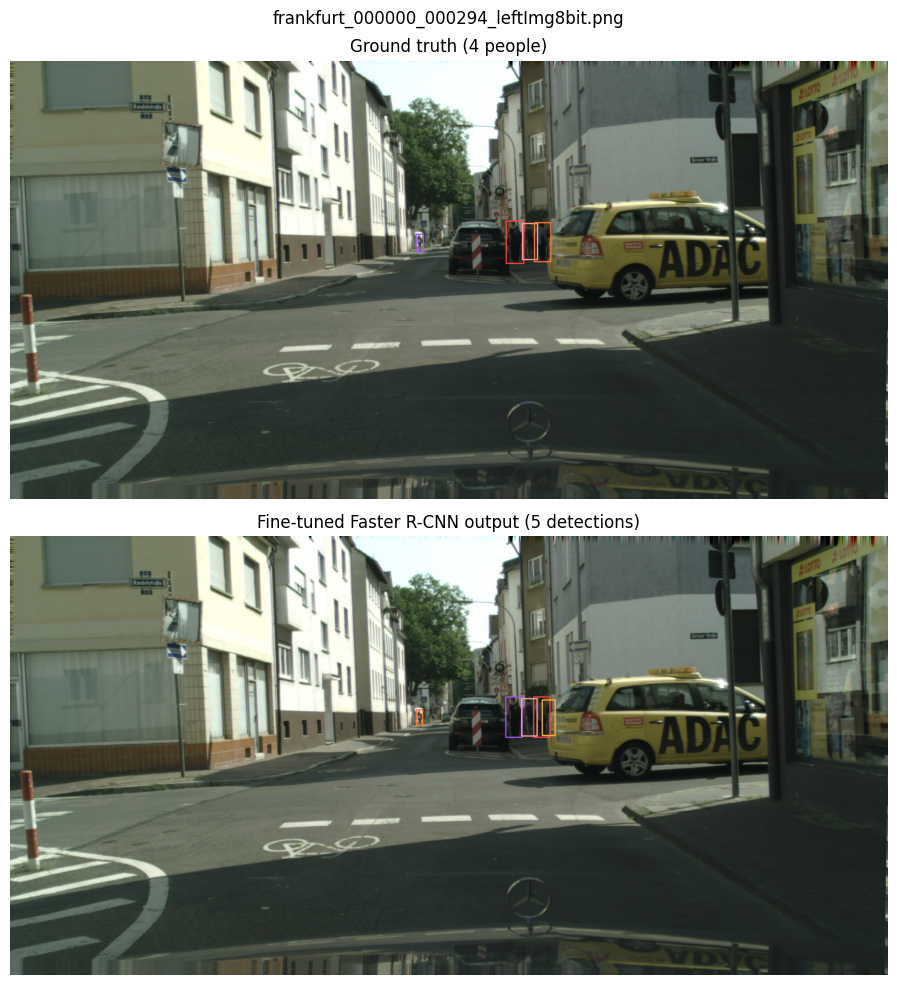

In [13]:
# Ground truth vs. fine-tuned detector output
sample = real_frames[0]
gt_sv = sv.Detections(xyxy=sample["gt"][:, :4].astype(np.float32)) if sample["gt"].shape[0] else sv.Detections.empty()
det_sv = sv.Detections(
    xyxy=sample["det"][:, :4].astype(np.float32),
    confidence=sample["det"][:, 4].astype(np.float32) if sample["det"].shape[0] else np.array([]),
) if sample["det"].shape[0] else sv.Detections.empty()

plain_box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.INDEX)
fig, axes = plt.subplots(2, 1, figsize=(20, 10))
axes[0].imshow(cv2.cvtColor(plain_box_annotator.annotate(sample["image"].copy(), gt_sv), cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Ground truth ({sample['gt'].shape[0]} people)")
axes[1].imshow(cv2.cvtColor(plain_box_annotator.annotate(sample["image"].copy(), det_sv), cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Fine-tuned Faster R-CNN output ({sample['det'].shape[0]} detections)")
for ax in axes:
    ax.axis("off")
plt.suptitle(sample["path"].name)
plt.tight_layout()
plt.show()


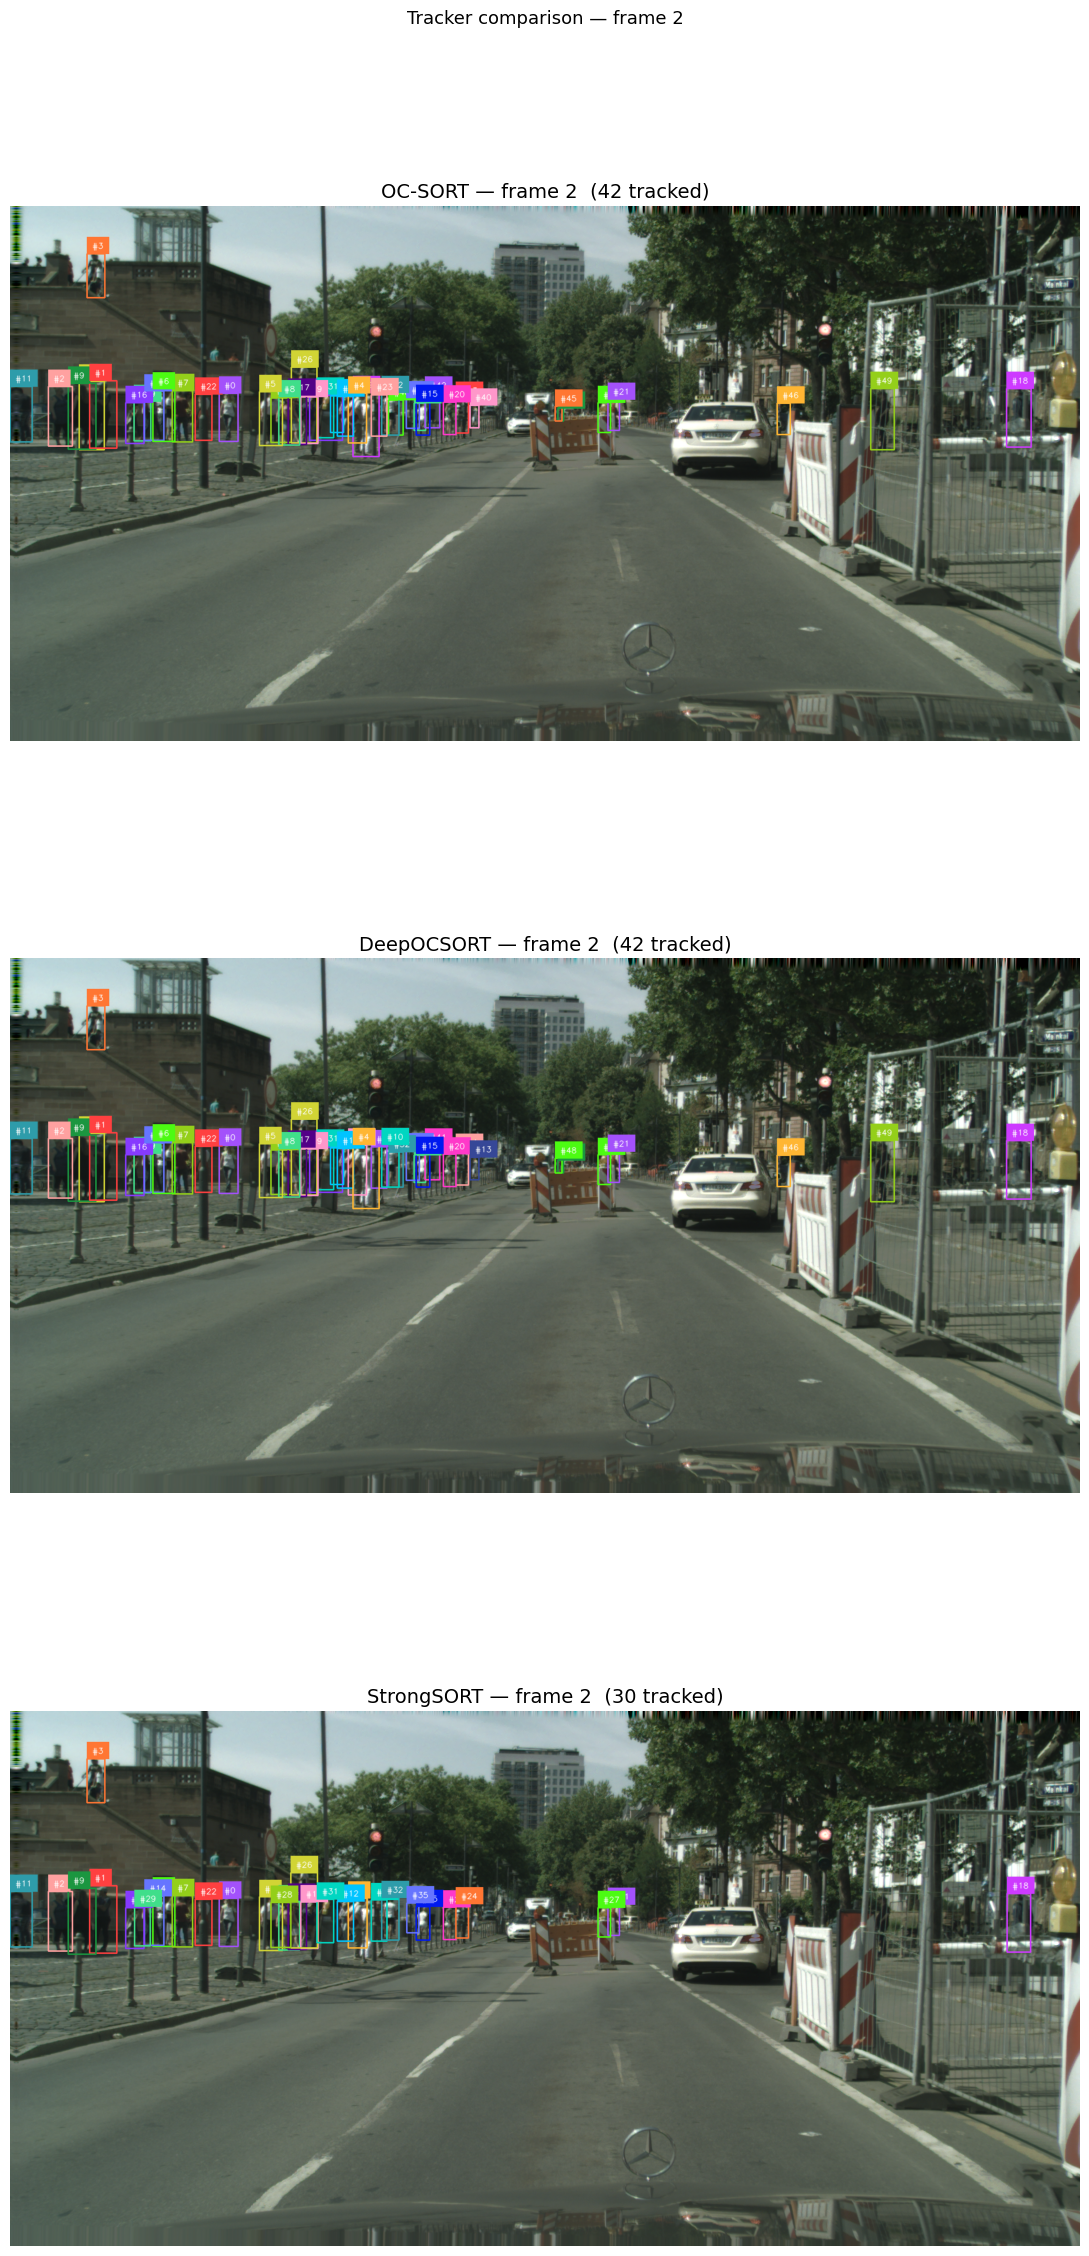

Tracks/frame, first 5 frames:
  OC-SORT      [39, 41, 42, 28, 31]
  DeepOCSORT   [39, 41, 42, 28, 31]
  StrongSORT   [0, 0, 30, 33, 34]


In [ ]:
# Comparing box annotation of the three trackers

def first_common_frame(results_by_tracker):
    n_frames = len(next(iter(results_by_tracker.values())))
    for i in range(n_frames):
        if all(res[i].shape[0] > 0 for res in results_by_tracker.values()):
            return i
    return 0  # fallback: nobody ever agrees, just show the first frame

frame_idx = first_common_frame(tracking_results)

fig, axes = plt.subplots(len(tracking_results), 1, figsize=(11, 8 * len(tracking_results)))
if len(tracking_results) == 1:
    axes = [axes]
for ax, name in zip(axes, tracking_results.keys()):
    annotated = annotated_results[name][frame_idx]
    n_boxes = tracking_results[name][frame_idx].shape[0]
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name} — frame {frame_idx}  ({n_boxes} tracked)", fontsize=14)
    ax.axis("off")
plt.suptitle(f"Tracker comparison — frame {frame_idx}",
             fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

print("Tracks/frame, first 5 frames:")
for name, res in tracking_results.items():
    print(f"  {name:12s} {[r.shape[0] for r in res[:5]]}")

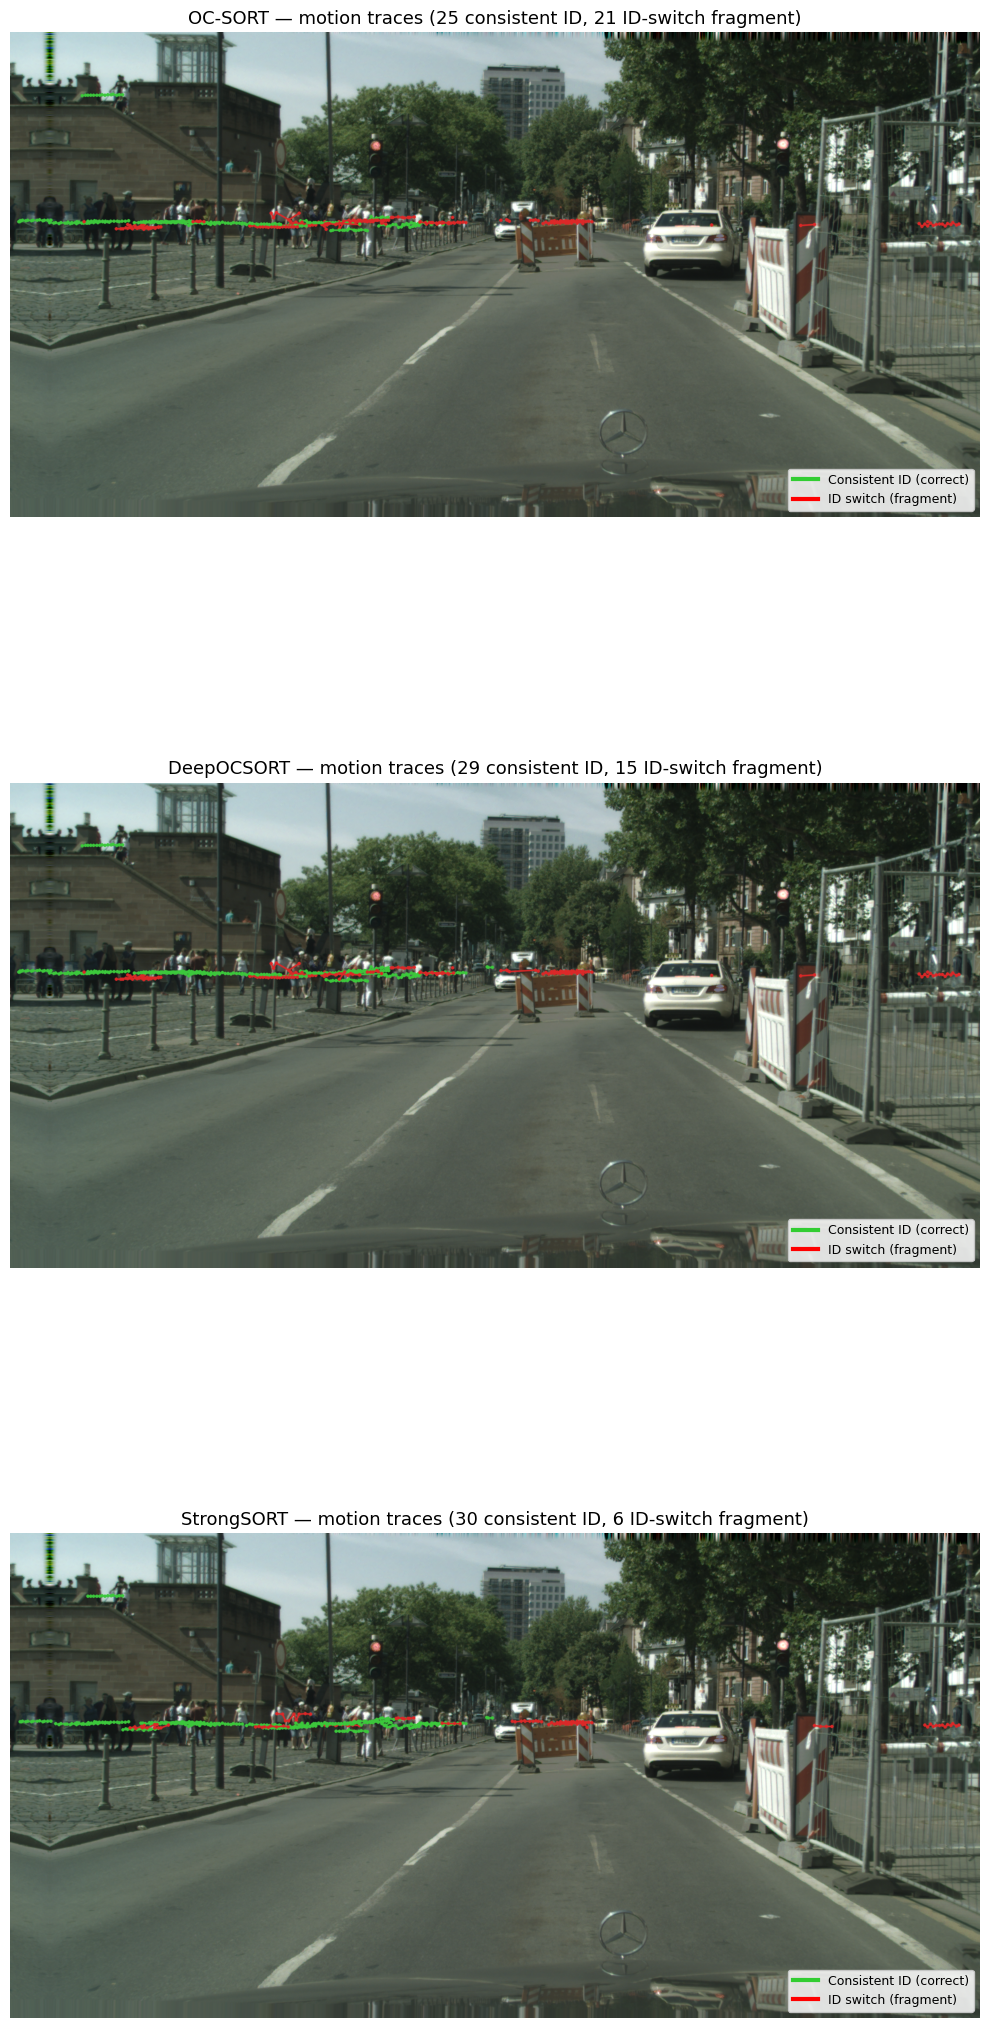

In [ ]:
# Motion trace visualization. Tracks consistent IDs (same person) vs. fragments (ID switches).

def reconstruct_identity_boxes(base_gt, frame_idx, pan_px):
    '''Where each real person "should" be at this frame, ignoring jitter'''
    boxes = base_gt[:, :4].copy()
    boxes[:, [0, 2]] += pan_px * frame_idx
    return boxes

# Compute the centroid of a bounding box
def box_centroid(box):
    x1, y1, x2, y2 = box
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0])

# Match a tracked box to the closest ground-truth identity box, ignoring occluded tracks
def match_identity(track_box, frame_idx, base_gt, pan_px, occlude_track, occlude_frames,
                    max_dist_px=40.0):
    ref_boxes = reconstruct_identity_boxes(base_gt, frame_idx, pan_px)
    occluded_now = occlude_track is not None and frame_idx in occlude_frames
    tc = box_centroid(track_box)
    best_id, best_dist = None, max_dist_px
    for pid, rb in enumerate(ref_boxes):
        if occluded_now and pid == occlude_track:
            continue
        d = np.linalg.norm(tc - box_centroid(rb))
        if d < best_dist:
            best_dist, best_id = d, pid
    return best_id

# Classify each track as accurate or a fragment based on its identity consistency
def classify_track_accuracy(results, base_gt, pan_px, occlude_track, occlude_frames):
    votes, first_frame = {}, {}
    # Count how many times each track_id votes for each identity (pid)
    for frame_idx, frame_res in enumerate(results):
        for row in frame_res:
            tid = int(row[4])
            pid = match_identity(row[:4], frame_idx, base_gt, pan_px, occlude_track, occlude_frames)
            if pid is None:
                continue
            votes.setdefault(tid, {}).setdefault(pid, 0)
            votes[tid][pid] += 1
            first_frame.setdefault(tid, frame_idx)

    # Determine the most-voted identity for each track_id
    track_to_identity = {tid: max(v, key=v.get) for tid, v in votes.items()}
    identity_to_first_track = {}

    # Map each identity to the first track that claimed it
    for tid in sorted(track_to_identity, key=lambda t: first_frame[t]):
        identity_to_first_track.setdefault(track_to_identity[tid], tid)

    accurate = {}
    # Classify each track as accurate or a fragment
    for tid, pid in track_to_identity.items():
        single_identity = len(votes[tid]) == 1
        is_original = identity_to_first_track[pid] == tid
        accurate[tid] = bool(single_identity and is_original)
    return accurate

# Draw motion traces for each track, colored by accuracy (green = consistent ID, red = fragment)
def draw_accuracy_traces(results, base_gt, pan_px, occlude_track, occlude_frames, base_canvas):
    accurate = classify_track_accuracy(results, base_gt, pan_px, occlude_track, occlude_frames)
    canvas = base_canvas.copy()
    paths = {}
    for frame_res in results:
        for row in frame_res:
            tid = int(row[4])
            paths.setdefault(tid, []).append(tuple(box_centroid(row[:4]).astype(int)))
    for tid, pts in paths.items():
        color = GREEN if accurate.get(tid, False) else RED
        for p1, p2 in zip(pts[:-1], pts[1:]):
            cv2.line(canvas, p1, p2, color, 2, lineType=cv2.LINE_AA)
        for p in pts:
            cv2.circle(canvas, p, 3, color, -1, lineType=cv2.LINE_AA)
    return canvas, accurate

# Visualize motion traces for each tracker, showing consistent IDs vs. fragments
n_trackers = len(tracking_results)
fig, axes = plt.subplots(n_trackers, 1, figsize=(10, 8 * n_trackers))
if n_trackers == 1:
    axes = [axes]

can_check_accuracy = (SEQUENCE_SOURCE == "synthetic")

# Draw motion traces for each tracker, using green for consistent IDs and red for fragments
for ax, (name, results) in zip(axes, tracking_results.items()):
    base_canvas = sequence[-1]["image"].copy()
    if can_check_accuracy:
        canvas, accurate = draw_accuracy_traces(
            results, base_frame["gt"], SYNTH_PARAMS["pan_px"],
            SYNTH_PARAMS["occlude_track"], SYNTH_PARAMS["occlude_frames"], base_canvas
        )
        n_ok, n_bad = sum(accurate.values()), len(accurate) - sum(accurate.values())
        subtitle = f"{n_ok} consistent ID, {n_bad} ID-switch fragment"
        ax.plot([], [], color="limegreen", linewidth=3, label="Consistent ID (correct)")
        ax.plot([], [], color="red", linewidth=3, label="ID switch (fragment)")
        ax.legend(loc="lower right", fontsize=9, framealpha=0.85)
    else:
        # fall back to Supervision's own trace annotator, colored per track id only.
        trace_annotator = sv.TraceAnnotator(trace_length=len(sequence))
        canvas = base_canvas
        for dets in sv_detections_results[name]:
            canvas = trace_annotator.annotate(canvas, dets)
        subtitle = "colored by track id (no ground-truth identity available in 'real' mode)"
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name} — motion traces ({subtitle})", fontsize=13)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Summarize identity consistency across trackers
def summarize_id_consistency(name, results, expected_identities):
    all_ids = set()
    for r in results:
        if r.shape[0]:
            all_ids.update(r[:, 4].astype(int).tolist())

    row = {
        "tracker": name,
        "expected_identities": expected_identities,
        "unique_ids_used": len(all_ids),
    }

    # In synthetic mode, check against ground-truth identities to classify tracks as consistent or fragments.
    if SEQUENCE_SOURCE == "synthetic":
        accurate = classify_track_accuracy(
            results, base_frame["gt"], SYNTH_PARAMS["pan_px"],
            SYNTH_PARAMS["occlude_track"], SYNTH_PARAMS["occlude_frames"]
        )
        n_consistent = sum(accurate.values())
        n_switch_fragments = len(accurate) - n_consistent
        n_unmatched = len(all_ids) - len(accurate)  # never matched to a real person, e.g. false positives
        row["consistent_ids"] = n_consistent
        row["id_switch_fragments"] = n_switch_fragments
        row["unmatched_ids_(false_positives)"] = n_unmatched
    else:
        # Fall back to the loose proxy.
        row["extra_ids_(id_switch_proxy)"] = max(0, len(all_ids) - expected_identities)

    return row


summary_rows = [summarize_id_consistency(name, res, n_identities)
                for name, res in tracking_results.items()]
summary_df = pd.DataFrame(summary_rows)
summary_df

,tracker,expected_identities,unique_ids_used,consistent_ids,id_switch_fragments,unmatched_ids_(false_positives)
0,OC-SORT,53,58,25,21,12
1,DeepOCSORT,53,55,29,15,11
2,StrongSORT,53,42,30,6,6


## Created annotated video from CityScapes frames.

In [ ]:
def run_video_pipeline_from_frames(frames_dir, tracker_name, tracker, detector_fn,
                                    output_path=OUTPUT_VIDEO_PATH, max_frames=None,
                                    resize_width=None, fps=FRAME_FPS, img_exts=IMG_EXTS):
    '''Reads folder of sequential frame images
    runs detector -> tracker -> Supervision-annotation loop and outputs an mp4.'''
    frames_dir = Path(frames_dir)
    if not frames_dir.exists():
        print(f"'{frames_dir}' not found")
        return

    frame_paths = sorted(
        p for p in frames_dir.iterdir() if p.suffix.lower() in img_exts
    )
    if not frame_paths:
        print(f"No images with extensions {img_exts} found in '{frames_dir}'.")
        return
    if max_frames is not None:
        frame_paths = frame_paths[:max_frames]
    print(f"Found {len(frame_paths)} frames in '{frames_dir}'")

    # Read the first frame to establish output resolution.
    first_frame = cv2.imread(str(frame_paths[0]))
    if first_frame is None:
        print(f"Could not read '{frame_paths[0]}'")
        return
    height, width = first_frame.shape[:2]
    if resize_width:
        scale = resize_width / width
        width = resize_width
        height = int(height * scale)

    box_ann = sv.BoxAnnotator(color_lookup=sv.ColorLookup.TRACK)
    label_ann = sv.LabelAnnotator(color_lookup=sv.ColorLookup.TRACK)
    trace_ann = sv.TraceAnnotator()

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    try:
        for i, frame_path in enumerate(frame_paths):
            frame = cv2.imread(str(frame_path))
            if frame is None:
                print(f"Skipping unreadable frame: {frame_path}")
                continue
            if resize_width:
                frame = cv2.resize(frame, (width, height))

            dets = detector_fn(frame)
            # OC-SORT is motion-only; DeepOCSORT/StrongSORT need appearance embeddings.
            if tracker_name == "OC-SORT":
                tracks = tracker.update(dets, frame)
            else:
                embs = extract_color_histogram_embeddings(frame, dets[:, :4])
                tracks = tracker.update(dets, frame, embs=embs)

            detections = boxmot_output_to_sv_detections(np.asarray(tracks))
            labels = [f"#{tid}" for tid in detections.tracker_id] if detections.tracker_id is not None else []
            annotated = box_ann.annotate(frame.copy(), detections)
            annotated = label_ann.annotate(annotated, detections, labels=labels)
            annotated = trace_ann.annotate(annotated, detections)
            writer.write(annotated)

            if (i + 1) % 25 == 0:
                print(f"  processed {i + 1}/{len(frame_paths)} frames")
    finally:
        writer.release()

    print(f"Done -> {output_path}")


# Use trained model to run on a folder of frames and produce a video with tracked boxes and traces.
# Swap trackers by changing TRACKER_NAME in the constants cell (no other code needs to change).
video_tracker = build_trackers()[TRACKER_NAME]
run_video_pipeline_from_frames(FRAMES_DIR, TRACKER_NAME, video_tracker, detect_pedestrians,
                                max_frames=MAX_FRAMES, resize_width=RESIZE_WIDTH)


INFO     OcSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,           
         class_ids=None, asso_func=iou, min_conf=0.1, delta_t=3, inertia=0.2, use_byte=False, Q_xy_scaling=0.01,   
         Q_s_scaling=0.0001

INFO     DeepOcSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,       
         class_ids=None, asso_func=iou, reid_model=None, delta_t=3, inertia=0.2, w_association_emb=0.5,            
         alpha_fixed_emb=0.95, aw_param=0.5, embedding_off=False, cmc_off=False, aw_off=False, Q_xy_scaling=0.01,  
         Q_s_scaling=0.0001

INFO     StrongSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,       
         class_ids=None, asso_func=iou, reid_model=None, min_conf=0.1, max_cos_dist=0.2, max_iou_dist=0.7,         
         n_init=3, nn_budget=100, mc_lambda=0.98, ema_alpha=0.9

Found 599 frames in 'stuttgart_00'
  processed 25/599 frames
  processed 50/599 frames
  processed 75/599 frames
  processed 100/599 frames
  processed 125/599 frames
  processed 150/599 frames
  processed 175/599 frames
  processed 200/599 frames
  processed 225/599 frames
  processed 250/599 frames
  processed 275/599 frames
  processed 300/599 frames
  processed 325/599 frames
  processed 350/599 frames
  processed 375/599 frames
  processed 400/599 frames
  processed 425/599 frames
  processed 450/599 frames
  processed 475/599 frames
  processed 500/599 frames
  processed 525/599 frames
  processed 550/599 frames
  processed 575/599 frames
Done -> tracked_output.mp4
